# 7. Tree-Based Model Experiments

## Objective

This notebook evaluates tree-based machine learning models for predicting
credit card payment default.

Previous Logistic Regression experiments showed that class weighting
significantly improved recall but reduced precision and accuracy.

Tree-based models are introduced to capture non-linear relationships and
interactions between customer characteristics, repayment behavior,
billing history, payment behavior, and engineered features.

The main objectives are:

- Build a Random Forest baseline model.
- Evaluate the effect of class weighting on Random Forest.
- Compare Random Forest with previous Logistic Regression baselines.
- Determine whether tree-based models improve default-risk detection.

The validation set is used for model comparison.

The test set remains untouched until the final model and decision threshold
have been selected.

## 1. Setup and Data Loading

Common modeling utilities are imported from the `src` package to avoid
duplicating data loading, splitting, preprocessing, leakage checks, and
evaluation logic across notebooks.

In [3]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(
    0,
    str(PROJECT_ROOT)
)


from src.modeling_utils import (
    load_data,
    split_data,
    build_preprocessor,
    evaluate_model
)


print("Project root:", PROJECT_ROOT)
print("Imports successful.")

Project root: d:\1-PERSONAL\HOC-TAP\DS\credit-risk-default-prediction
Imports successful.


In [4]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "credit_default_features.csv"
)

X, y = load_data(DATA_PATH)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 36)
y shape: (30000,)


## 2. Train-Validation-Test Split

The same stratified 70/15/15 split used in previous experiments is reused
to ensure a fair comparison between models.

- Training set: model fitting.
- Validation set: model comparison.
- Test set: final evaluation only.

In [5]:
(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test
) = split_data(X, y)


print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (21000, 36)
Validation: (4500, 36)
Test: (4500, 36)


## 3. Random Forest Baseline

Random Forest is an ensemble tree-based model capable of learning
non-linear relationships and feature interactions.

Unlike Logistic Regression, Random Forest does not require numerical
feature standardization.

Therefore:

- Numerical features are passed through without scaling.
- Categorical features are one-hot encoded.

In [6]:
tree_preprocessor = build_preprocessor(
    X,
    scale_numeric=False
)

tree_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [7]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [8]:
rf_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['LIMIT_BAL','SEX','EDUCATION',...,'AVG_CREDIT_UTILIZATION', 'PAYMENT_TO_BILL_RATIO','BILL_CHANGE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [9]:
rf_results = evaluate_model(
    rf_pipeline,
    X_val,
    y_val,
    "Random Forest"
)

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.814,
 'Precision': 0.6390845070422535,
 'Recall': 0.36482412060301506,
 'F1': 0.46449136276391556,
 'ROC_AUC': 0.7589208524792294,
 'PR_AUC': 0.5339741379138274}

### Random Forest Confusion Matrix

The confusion matrix is used to examine the types of classification errors.

Particular attention is given to false negatives because they represent
customers who actually default but are predicted as non-default.

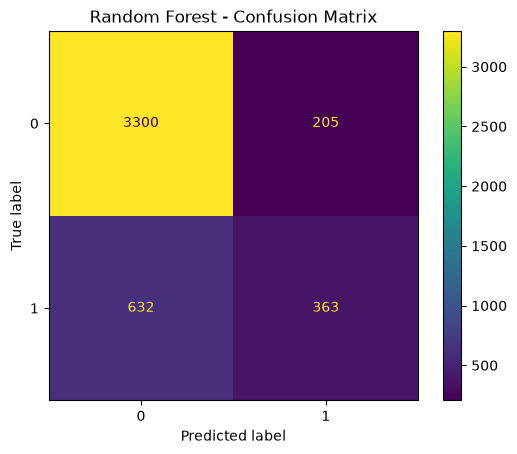

In [10]:
rf_pred = rf_pipeline.predict(
    X_val
)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    rf_pred
)

plt.title(
    "Random Forest - Confusion Matrix"
)

plt.show()

In [11]:
tn, fp, fn, tp = confusion_matrix(
    y_val,
    rf_pred
).ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 3300
False Positive: 205
False Negative: 632
True Positive : 363


In [12]:
rf_balanced_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [13]:
rf_balanced_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['LIMIT_BAL','SEX','EDUCATION',...,'AVG_CREDIT_UTILIZATION', 'PAYMENT_TO_BILL_RATIO','BILL_CHANGE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [14]:
rf_balanced_results = evaluate_model(
    rf_balanced_pipeline,
    X_val,
    y_val,
    "Random Forest (Balanced)"
)

rf_balanced_results

{'Model': 'Random Forest (Balanced)',
 'Accuracy': 0.7977777777777778,
 'Precision': 0.5492468134414832,
 'Recall': 0.4763819095477387,
 'F1': 0.5102260495156081,
 'ROC_AUC': 0.7624025978680851,
 'PR_AUC': 0.5319803520326016}

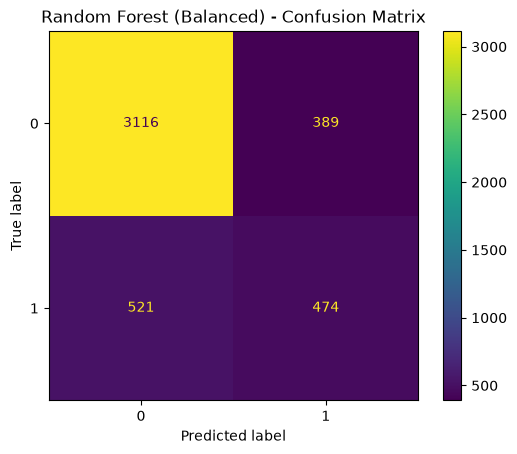

In [15]:
rf_balanced_pred = (
    rf_balanced_pipeline.predict(X_val)
)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    rf_balanced_pred
)

plt.title(
    "Random Forest (Balanced) - Confusion Matrix"
)

plt.show()

In [16]:
tn_b, fp_b, fn_b, tp_b = confusion_matrix(
    y_val,
    rf_balanced_pred
).ravel()

print("True Negative :", tn_b)
print("False Positive:", fp_b)
print("False Negative:", fn_b)
print("True Positive :", tp_b)

True Negative : 3116
False Positive: 389
False Negative: 521
True Positive : 474


## 5. Model Comparison

The Random Forest models are compared with the previous baseline models
using the same validation set.

This provides a consistent comparison between linear and tree-based
classification approaches.

In [17]:
BASELINE_RESULTS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "baseline_results.csv"
)

baseline_results = pd.read_csv(
    BASELINE_RESULTS_PATH
)

baseline_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dummy Classifier,0.778889,0.000000,0.000000,0.000000,0.500000,0.221111
1,Logistic Regression,0.809778,0.643299,0.313568,0.421622,0.755626,0.510897
2,Logistic Regression (Balanced),0.746444,0.445522,0.600000,0.511349,0.760086,0.508136


In [18]:
tree_results = pd.DataFrame([
    rf_results,
    rf_balanced_results
])

In [19]:
comparison = pd.concat(
    [
        baseline_results,
        tree_results
    ],
    ignore_index=True
)

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dummy Classifier,0.7789,0.0000,0.0000,0.0000,0.5000,0.2211
1,Logistic Regression,0.8098,0.6433,0.3136,0.4216,0.7556,0.5109
2,Logistic Regression (Balanced),0.7464,0.4455,0.6000,0.5113,0.7601,0.5081
3,Random Forest,0.8140,0.6391,0.3648,0.4645,0.7589,0.5340
4,Random Forest (Balanced),0.7978,0.5492,0.4764,0.5102,0.7624,0.5320


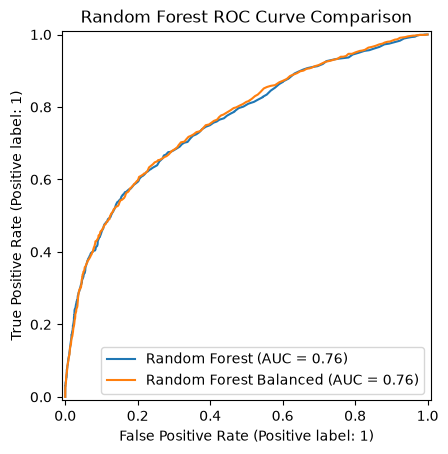

In [20]:
ax = plt.gca()

RocCurveDisplay.from_estimator(
    rf_pipeline,
    X_val,
    y_val,
    name="Random Forest",
    ax=ax
)

RocCurveDisplay.from_estimator(
    rf_balanced_pipeline,
    X_val,
    y_val,
    name="Random Forest Balanced",
    ax=ax
)

plt.title(
    "Random Forest ROC Curve Comparison"
)

plt.show()

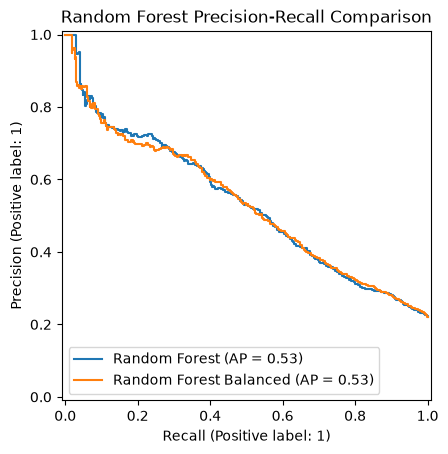

In [21]:
ax = plt.gca()

PrecisionRecallDisplay.from_estimator(
    rf_pipeline,
    X_val,
    y_val,
    name="Random Forest",
    ax=ax
)

PrecisionRecallDisplay.from_estimator(
    rf_balanced_pipeline,
    X_val,
    y_val,
    name="Random Forest Balanced",
    ax=ax
)

plt.title(
    "Random Forest Precision-Recall Comparison"
)

plt.show()

## 6. Random Forest Findings

The Random Forest models improved several validation metrics compared with
the original Logistic Regression baseline.

The standard Random Forest achieved:

- Accuracy: 81.40%
- Precision: 63.91%
- Recall: 36.48%
- F1-score: 46.45%
- ROC-AUC: 75.89%
- PR-AUC: 53.40%

Applying balanced class weights increased recall from 36.48% to 47.64%
and improved the F1-score to 51.02%.

The Balanced Random Forest also achieved the highest ROC-AUC among the
models evaluated so far at 76.24%, while maintaining a PR-AUC of 53.20%.

However, Logistic Regression with balanced class weights still achieved
the highest recall at 60.00%.

These results demonstrate a trade-off between identifying more default
customers and maintaining precision and overall accuracy.

Further evaluation using gradient boosting models is required before
selecting the final model.

## 7. XGBoost

XGBoost is a gradient boosting algorithm that builds decision trees
sequentially, where each new tree attempts to correct errors made by
previous trees.

Compared with Random Forest, which builds many trees independently,
XGBoost builds trees iteratively and focuses on difficult observations.

Two experiments are performed:

- Standard XGBoost.
- XGBoost with class imbalance handling using `scale_pos_weight`.

The same training and validation sets are used to ensure a fair comparison
with previous models.

The test set remains untouched.

In [22]:
from xgboost import XGBClassifier

### 7.1 XGBoost Baseline

The first XGBoost model is trained without additional class weighting.

This provides a baseline for evaluating whether gradient boosting improves
predictive performance compared with Logistic Regression and Random Forest.

In [24]:
tree_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [25]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [26]:
xgb_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['LIMIT_BAL','SEX','EDUCATION',...,'AVG_CREDIT_UTILIZATION', 'PAYMENT_TO_BILL_RATIO','BILL_CHANGE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [27]:
xgb_results = evaluate_model(
    xgb_pipeline,
    X_val,
    y_val,
    "XGBoost"
)

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.816,
 'Precision': 0.6537753222836096,
 'Recall': 0.35678391959798994,
 'F1': 0.4616384915474642,
 'ROC_AUC': 0.779213901174919,
 'PR_AUC': 0.5531582879847922}

### XGBoost Confusion Matrix

The confusion matrix is examined to determine how many actual default
customers are detected and how many are missed by the XGBoost model.

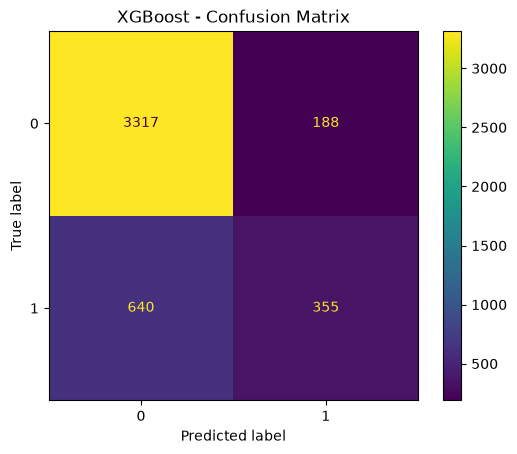

In [28]:
xgb_pred = xgb_pipeline.predict(
    X_val
)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    xgb_pred
)

plt.title(
    "XGBoost - Confusion Matrix"
)

plt.show()

In [29]:
tn_xgb, fp_xgb, fn_xgb, tp_xgb = confusion_matrix(
    y_val,
    xgb_pred
).ravel()

print("True Negative :", tn_xgb)
print("False Positive:", fp_xgb)
print("False Negative:", fn_xgb)
print("True Positive :", tp_xgb)

True Negative : 3317
False Positive: 188
False Negative: 640
True Positive : 355


## 8. XGBoost with Class Imbalance Handling

XGBoost handles class imbalance using `scale_pos_weight`.

The value is calculated from the training set as:

negative samples / positive samples

This gives greater importance to errors involving the minority default class.

The objective is to determine whether class weighting improves recall
without excessively reducing precision.

In [30]:
negative_count = (
    y_train == 0
).sum()

positive_count = (
    y_train == 1
).sum()

scale_pos_weight = (
    negative_count
    / positive_count
)

print(
    "Negative samples:",
    negative_count
)

print(
    "Positive samples:",
    positive_count
)

print(
    "scale_pos_weight:",
    round(scale_pos_weight, 4)
)

Negative samples: 16355
Positive samples: 4645
scale_pos_weight: 3.521


In [31]:
xgb_balanced_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [32]:
xgb_balanced_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['LIMIT_BAL','SEX','EDUCATION',...,'AVG_CREDIT_UTILIZATION', 'PAYMENT_TO_BILL_RATIO','BILL_CHANGE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [33]:
xgb_balanced_results = evaluate_model(
    xgb_balanced_pipeline,
    X_val,
    y_val,
    "XGBoost (Balanced)"
)

xgb_balanced_results

{'Model': 'XGBoost (Balanced)',
 'Accuracy': 0.7586666666666667,
 'Precision': 0.4658151765589782,
 'Recall': 0.6231155778894473,
 'F1': 0.5331040412725709,
 'ROC_AUC': 0.7783799167019118,
 'PR_AUC': 0.5554444715715462}

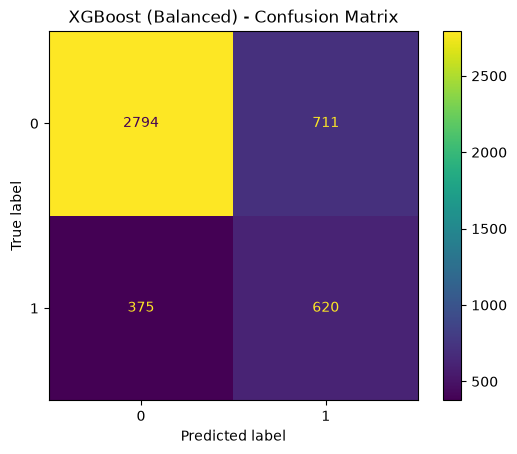

In [34]:
xgb_balanced_pred = (
    xgb_balanced_pipeline.predict(X_val)
)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    xgb_balanced_pred
)

plt.title(
    "XGBoost (Balanced) - Confusion Matrix"
)

plt.show()

In [35]:
tn_xgb_b, fp_xgb_b, fn_xgb_b, tp_xgb_b = (
    confusion_matrix(
        y_val,
        xgb_balanced_pred
    ).ravel()
)

print("True Negative :", tn_xgb_b)
print("False Positive:", fp_xgb_b)
print("False Negative:", fn_xgb_b)
print("True Positive :", tp_xgb_b)

True Negative : 2794
False Positive: 711
False Negative: 375
True Positive : 620


In [36]:
comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dummy Classifier,0.778889,0.000000,0.000000,0.000000,0.500000,0.221111
1,Logistic Regression,0.809778,0.643299,0.313568,0.421622,0.755626,0.510897
2,Logistic Regression (Balanced),0.746444,0.445522,0.600000,0.511349,0.760086,0.508136
3,Random Forest,0.814000,0.639085,0.364824,0.464491,0.758921,0.533974
4,Random Forest (Balanced),0.797778,0.549247,0.476382,0.510226,0.762403,0.531980


In [37]:
xgb_results_df = pd.DataFrame([
    xgb_results,
    xgb_balanced_results
])

In [38]:
comparison = pd.concat(
    [
        comparison,
        xgb_results_df
    ],
    ignore_index=True
)

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dummy Classifier,0.7789,0.0000,0.0000,0.0000,0.5000,0.2211
1,Logistic Regression,0.8098,0.6433,0.3136,0.4216,0.7556,0.5109
2,Logistic Regression (Balanced),0.7464,0.4455,0.6000,0.5113,0.7601,0.5081
3,Random Forest,0.8140,0.6391,0.3648,0.4645,0.7589,0.5340
4,Random Forest (Balanced),0.7978,0.5492,0.4764,0.5102,0.7624,0.5320
5,XGBoost,0.8160,0.6538,0.3568,0.4616,0.7792,0.5532
6,XGBoost (Balanced),0.7587,0.4658,0.6231,0.5331,0.7784,0.5554


## 10. XGBoost Findings

XGBoost provided stronger predictive performance than the previous
Logistic Regression and Random Forest baselines.

The standard XGBoost model achieved:

- Accuracy: 81.60%
- Precision: 65.38%
- Recall: 35.68%
- F1-score: 46.16%
- ROC-AUC: 77.92%
- PR-AUC: 55.32%

After applying class imbalance handling using `scale_pos_weight`,
the Balanced XGBoost model achieved:

- Accuracy: 75.87%
- Precision: 46.58%
- Recall: 62.31%
- F1-score: 53.31%
- ROC-AUC: 77.84%
- PR-AUC: 55.54%

The balanced model substantially improved recall, allowing the model
to identify more customers who actually default.

This improvement comes at the cost of lower precision and accuracy,
demonstrating the trade-off between detecting default customers and
generating additional false-positive predictions.

Among the models evaluated so far, Balanced XGBoost achieved the highest
recall, F1-score, and PR-AUC, while standard XGBoost achieved the highest
accuracy, precision, and ROC-AUC.

These results make XGBoost the main candidate for further model tuning
and decision-threshold optimization.

In [39]:
RESULTS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "model_comparison.csv"
)

comparison.to_csv(
    RESULTS_PATH,
    index=False
)

print("Saved results to:", RESULTS_PATH)

Saved results to: d:\1-PERSONAL\HOC-TAP\DS\credit-risk-default-prediction\reports\model_comparison.csv
